# ECB Shock Regressions

This notebook keeps the same underlying shock and duration inputs, but refactors the regression workflow for readability, comparability, and compact thesis-ready output tables.

## 0. Variable Naming (Short Guide)

Dependent variables:
- `AR_0`: event-day abnormal return
- `AR_0_1`: event-day plus next-day abnormal return
- `AR_m1_1`: placebo window from previous day to next day (if available)

Shock variables:
- `ShockMP`: monetary-policy shock (`MP_median`)
- `ShockInfo`: information shock (`CBI_median`)

Duration variables:
- `Duration_Implied_std`
- `Duration_NetPayout_std`

Controls (if available and standardized):
- `beta_std`
- `log_mcap_std`
- `leverage_std`
- `bm_std`

## 1. Load data

In [13]:
import numpy as np
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR
TABLE_DIR = BASE_DIR / 'tables'
GRAPH_DIR = BASE_DIR / 'graphs'

RET_PATH = DATA_DIR / 'euro500_daily_returns.parquet'
SHOCK_PATH = DATA_DIR / 'shocks_ecb_mpd_me_d.csv'
DUR_IMP_PATH = DATA_DIR / 'implied_duration_firmyear.parquet'
DUR_NP_PATH = DATA_DIR / 'EQDuration_Netpayout.parquet'

for p in [RET_PATH, SHOCK_PATH, DUR_IMP_PATH, DUR_NP_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required input: {p}')

df_ret = pd.read_parquet(RET_PATH)
df_shock = pd.read_csv(SHOCK_PATH)
df_imp = pd.read_parquet(DUR_IMP_PATH)
df_np = pd.read_parquet(DUR_NP_PATH)

print('Loaded shapes:')
print('returns   :', df_ret.shape)
print('shocks    :', df_shock.shape)
print('implied   :', df_imp.shape)
print('netpayout :', df_np.shape)

set_global_plot_style()

Loaded shapes:
returns   : (3457796, 13)
shocks    : (312, 7)
implied   : (12325, 40)
netpayout : (56500, 47)


## 2. Prepare event panel

In [14]:
def first_existing(df, candidates, required=False, label='column'):
    col = next((c for c in candidates if c in df.columns), None)
    if required and col is None:
        raise KeyError(f'Missing {label}. Tried: {candidates}')
    return col

def merge_last_available_feature(events, features, value_col, event_date_col='date', feature_date_col='asof_effective_date', key_priority=('RIC', 'firm_id')):
    key = next((k for k in key_priority if k in events.columns and k in features.columns), None)
    if key is None:
        raise ValueError(f'No common merge key for {value_col}. Tried {key_priority}')

    left = events.copy()
    left[event_date_col] = pd.to_datetime(left[event_date_col], errors='coerce').dt.normalize()
    left['_row_order'] = np.arange(len(left))

    right = features[[key, feature_date_col, value_col]].copy()
    right[feature_date_col] = pd.to_datetime(right[feature_date_col], errors='coerce').dt.normalize()

    valid_left = left[event_date_col].notna() & left[key].notna()
    valid_right = right[feature_date_col].notna() & right[key].notna() & right[value_col].notna()
    l_ok = left.loc[valid_left].copy()
    r_ok = right.loc[valid_right].copy()

    if l_ok.empty or r_ok.empty:
        left[value_col] = np.nan
        return left.drop(columns=['_row_order']), key

    chunks = []
    for k_val, l_grp in l_ok.groupby(key, sort=False):
        r_grp = r_ok[r_ok[key] == k_val].sort_values(feature_date_col)
        if r_grp.empty:
            l_grp[value_col] = np.nan
            chunks.append(l_grp)
            continue
        l_grp = l_grp.sort_values(event_date_col)
        merged = pd.merge_asof(
            l_grp,
            r_grp[[feature_date_col, value_col]],
            left_on=event_date_col,
            right_on=feature_date_col,
            direction='backward',
            allow_exact_matches=True,
        )
        chunks.append(merged.drop(columns=[feature_date_col], errors='ignore'))

    out_ok = pd.concat(chunks, axis=0) if chunks else l_ok.copy()
    left = left.merge(out_ok[['_row_order', value_col]], on='_row_order', how='left')
    left = left.sort_values('_row_order').drop(columns=['_row_order'])
    return left, key


def merge_strict_quarter_feature(events, features, value_col, event_date_col='date', feature_date_col='asof_effective_date', key_priority=('RIC', 'firm_id')):
    key = next((k for k in key_priority if k in events.columns and k in features.columns), None)
    if key is None:
        raise ValueError(f'No common merge key for {value_col}. Tried {key_priority}')

    left = events.copy()
    left[event_date_col] = pd.to_datetime(left[event_date_col], errors='coerce').dt.normalize()
    left['_event_quarter'] = left[event_date_col].dt.to_period('Q')

    right = features[[key, feature_date_col, value_col]].copy()
    right[feature_date_col] = pd.to_datetime(right[feature_date_col], errors='coerce').dt.normalize()
    right['_event_quarter'] = right[feature_date_col].dt.to_period('Q')

    valid_right = right[key].notna() & right['_event_quarter'].notna() & right[value_col].notna()
    right = right.loc[valid_right].copy()

    if right.empty:
        left[value_col] = np.nan
        return left.drop(columns=['_event_quarter']), key

    if pd.api.types.is_numeric_dtype(right[value_col]):
        right_q = right.groupby([key, '_event_quarter'], as_index=False)[value_col].median()
    else:
        right_q = (
            right.sort_values(feature_date_col)
                 .groupby([key, '_event_quarter'], as_index=False)[value_col]
                 .first()
        )

    left = left.merge(right_q, on=[key, '_event_quarter'], how='left')
    left = left.drop(columns=['_event_quarter'])
    return left, key

# Harmonize shocks
df_shock = df_shock.copy()
df_shock['date'] = pd.to_datetime(df_shock['date'], errors='coerce').dt.normalize()
shock_mp_col = first_existing(df_shock, ['MP_median'], required=True, label='ShockMP source')
shock_info_col = first_existing(df_shock, ['CBI_median'], required=True, label='ShockInfo source')
df_shock = df_shock.rename(columns={shock_mp_col: 'ShockMP', shock_info_col: 'ShockInfo'})
df_shock = df_shock[['date', 'ShockMP', 'ShockInfo']].dropna().drop_duplicates('date').sort_values('date')

# Harmonize returns and build windows
df_ret = df_ret.copy()
df_ret['date'] = pd.to_datetime(df_ret['date'], errors='coerce').dt.normalize()
df_ret['RIC'] = df_ret.get('RIC', pd.Series(index=df_ret.index, dtype='object')).astype('string').str.strip()
if 'firm_id' not in df_ret.columns:
    df_ret['firm_id'] = df_ret['RIC']
df_ret['AR_0'] = pd.to_numeric(df_ret['abnormal_return'], errors='coerce')
df_ret = df_ret.sort_values(['firm_id', 'date'])
df_ret['AR_lead1'] = df_ret.groupby('firm_id', dropna=False)['AR_0'].shift(-1)
df_ret['AR_lag1'] = df_ret.groupby('firm_id', dropna=False)['AR_0'].shift(1)
df_ret['AR_0_1'] = df_ret['AR_0'] + df_ret['AR_lead1']
df_ret['AR_m1_1'] = df_ret['AR_lag1'] + df_ret['AR_0'] + df_ret['AR_lead1']

# Keep event dates only
event_dates = set(df_shock['date'].dropna().unique())
df_evt = df_ret[df_ret['date'].isin(event_dates)].copy()
df_evt = df_evt.merge(df_shock, on='date', how='left', validate='m:1')
df_evt['event_date'] = df_evt['date']
df_evt['year_pred'] = (df_evt['date'].dt.year - 1).astype('Int64')

print('Event panel shape:', df_evt.shape)
print('Number of unique events:', df_evt['event_date'].nunique())

Event panel shape: (151024, 22)
Number of unique events: 312


### Coverage Check (End of Step 2)

This reproduces the key coverage diagnostic: share of event-panel observations with available predetermined duration (`last available <= event date`) for Macaulay and NetPayout.

,Duration,Coverage %,Covered Obs,Total Obs
0,Duration_Implied,0.000000,0,56500
1,Duration_NetPayout,76.184071,43044,56500


Combined coverage plot saved to: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/duration_coverage_rate_quarter_event.png


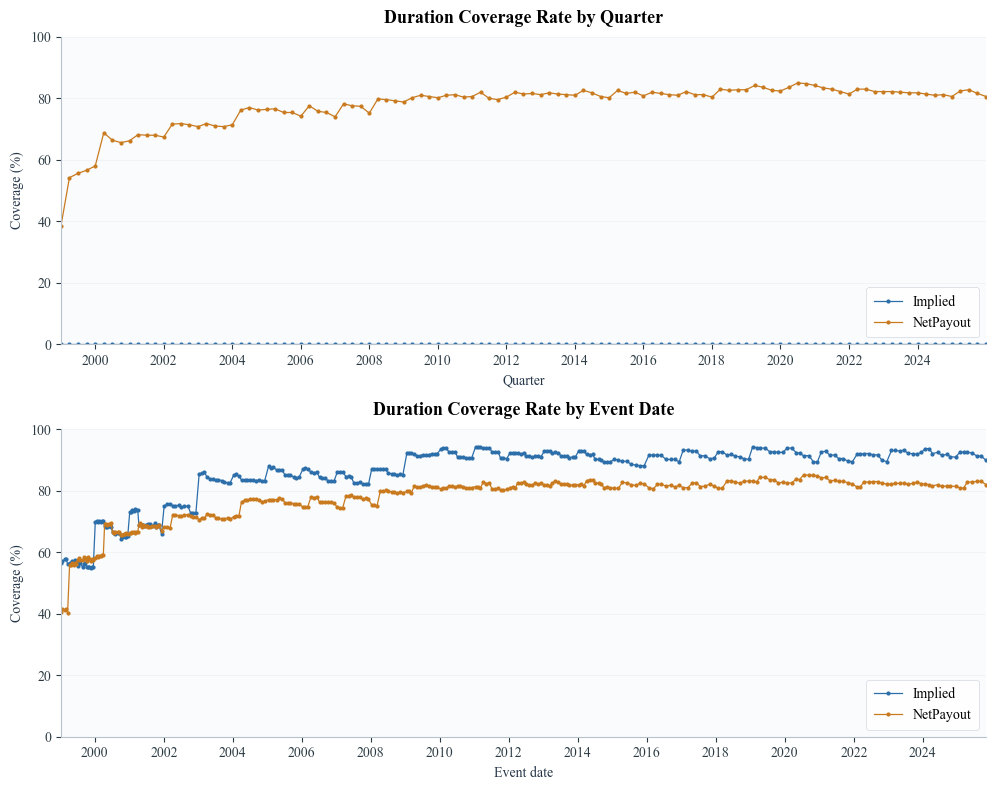

In [15]:
# Coverage diagnostic: duration-panel coverage by quarter / year
# Implied duration is annual (firm-year); NetPayout is quarterly.
# We assign implied obs to Dec-31 of each year for the time-series coverage plot.

def _prep_duration_for_coverage(df_in, duration_candidates):
    d = df_in.copy()

    if 'status' in d.columns:
        d = d[d['status'].eq('ok')].copy()

    dur_col = first_existing(d, duration_candidates, required=True, label='duration column for coverage')
    date_col = first_existing(
        d,
        ['effective_date', 'asof_effective_date', 'asof_date', 'date', 'formation_date'],
        required=False,
        label='as-of date for coverage',
    )

    # Implied duration: year-based — synthesize Dec-31 date
    if date_col is None:
        if 'year' not in d.columns:
            raise ValueError('Coverage prep: no date or year column found.')
        d['asof_effective_date'] = pd.to_datetime(d['year'].astype(str) + '-12-31', errors='coerce')
    else:
        d['asof_effective_date'] = pd.to_datetime(d[date_col], errors='coerce').dt.normalize()

    d['duration_value'] = pd.to_numeric(d[dur_col], errors='coerce')

    key_cols = [c for c in ['RIC', 'firm_id'] if c in d.columns]
    if not key_cols:
        raise ValueError('Coverage prep requires RIC or firm_id in duration input.')

    d = d[key_cols + ['asof_effective_date', 'duration_value']].dropna(subset=['asof_effective_date']).copy()

    grp_keys = key_cols + ['asof_effective_date']
    d = d.groupby(grp_keys, as_index=False)['duration_value'].median()
    return d

imp_cov_panel = _prep_duration_for_coverage(
    df_imp,
    ['implied_duration'],
).rename(columns={'duration_value': 'Duration_Implied'})

np_cov_panel = _prep_duration_for_coverage(
    df_np,
    ['Duration_NetPayout_trim', 'Duration_NetPayout', 'Duration_NP_trim', 'Duration_NP', 'NP_Duration'],
).rename(columns={'duration_value': 'Duration_NetPayout'})

# Combine and collapse duplicates on shared keys
cov_frames = [imp_cov_panel, np_cov_panel]
df_cov = pd.concat(cov_frames, ignore_index=True, sort=False)
key_cols = [c for c in ['RIC', 'firm_id', 'asof_effective_date'] if c in df_cov.columns]

num_cols = [c for c in ['Duration_Implied', 'Duration_NetPayout'] if c in df_cov.columns]
df_cov = df_cov.groupby(key_cols, as_index=False)[num_cols].median()

# Overall coverage table
n_panel = len(df_cov)
cov_overall = pd.DataFrame(
    {
        'Duration': ['Duration_Implied', 'Duration_NetPayout'],
        'Coverage %': [
            100 * df_cov['Duration_Implied'].notna().mean() if 'Duration_Implied' in df_cov.columns and n_panel > 0 else np.nan,
            100 * df_cov['Duration_NetPayout'].notna().mean() if 'Duration_NetPayout' in df_cov.columns and n_panel > 0 else np.nan,
        ],
        'Covered Obs': [
            int(df_cov['Duration_Implied'].notna().sum()) if 'Duration_Implied' in df_cov.columns else np.nan,
            int(df_cov['Duration_NetPayout'].notna().sum()) if 'Duration_NetPayout' in df_cov.columns else np.nan,
        ],
        'Total Obs': [n_panel, n_panel],
    }
)
display(cov_overall)

# Coverage by quarter/year
cov_q = df_cov.copy()
cov_q['quarter'] = pd.to_datetime(cov_q['asof_effective_date'], errors='coerce').dt.to_period('Q').dt.to_timestamp()
cov_q = cov_q.dropna(subset=['quarter'])

cov_plot = (
    cov_q.groupby('quarter', as_index=True)[['Duration_Implied', 'Duration_NetPayout']]
    .apply(lambda g: g.notna().mean())
    .sort_index()
)

# Coverage by event date (year-based match for Implied; quarter match for NetPayout)
cov_evt = df_evt[['event_date', 'date', 'RIC', 'firm_id', 'year_pred']].copy()

# Implied: match on year (year_pred = event_date.year - 1)
imp_yr = df_imp[['firm_id', 'year', 'implied_duration']].copy()
imp_yr['year'] = pd.to_numeric(imp_yr['year'], errors='coerce')
cov_evt['year_pred_int'] = pd.to_numeric(cov_evt['year_pred'], errors='coerce')
cov_evt = cov_evt.merge(
    imp_yr.rename(columns={'implied_duration': 'Duration_Implied'}),
    left_on=['firm_id', 'year_pred_int'],
    right_on=['firm_id', 'year'],
    how='left',
).drop(columns=['year'], errors='ignore')

cov_evt, _ = merge_strict_quarter_feature(
    cov_evt,
    np_cov_panel,
    'Duration_NetPayout',
    event_date_col='event_date',
    feature_date_col='asof_effective_date',
    key_priority=('RIC', 'firm_id'),
)

cov_by_event = (
    cov_evt.groupby('event_date', as_index=False)[['Duration_Implied', 'Duration_NetPayout']]
    .agg(lambda s: s.notna().mean())
    .sort_values('event_date')
    .dropna(subset=['event_date'])
)

# One combined PNG with both coverage charts stacked vertically
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
has_any_plot = False

# Top panel: Coverage by quarter
ax_q = axes[0]
if cov_plot.empty:
    ax_q.text(0.5, 0.5, 'No quarterly coverage observations available.', ha='center', va='center')
    ax_q.set_axis_off()
else:
    has_any_plot = True
    ax_q.plot(
        cov_plot.index,
        cov_plot['Duration_Implied'] * 100,
        marker='o',
        markersize=2.0,
        linewidth=0.9,
        label='Implied',
        color=COLORS['blue'],
    )
    ax_q.plot(
        cov_plot.index,
        cov_plot['Duration_NetPayout'] * 100,
        marker='o',
        markersize=2.0,
        linewidth=0.9,
        label='NetPayout',
        color=COLORS['orange'],
    )

    ax_q.set_title('Duration Coverage Rate by Quarter')
    ax_q.set_xlabel('Quarter')
    ax_q.set_ylabel('Coverage (%)')
    ax_q.set_ylim(0, 100)

    style_axes(ax_q, grid_axis='y', grid_alpha=0.25)
    x_min = pd.Timestamp('1999-01-01')
    x_max = min(pd.Timestamp('2025-12-31'), pd.to_datetime(cov_plot.index.max()))
    style_time_axis(
        ax_q,
        x_min=x_min,
        x_max=x_max,
        x_ticks=cov_plot.index,
        date_fmt='%Y',
    )
    style_legend(ax_q, loc='lower right')

# Bottom panel: Coverage by event date
ax_e = axes[1]
if cov_by_event.empty:
    ax_e.text(0.5, 0.5, 'No event-level coverage observations available.', ha='center', va='center')
    ax_e.set_axis_off()
else:
    has_any_plot = True
    ax_e.plot(
        cov_by_event['event_date'],
        cov_by_event['Duration_Implied'] * 100,
        marker='o',
        markersize=2.0,
        linewidth=0.9,
        label='Implied',
        color=COLORS['blue'],
    )
    ax_e.plot(
        cov_by_event['event_date'],
        cov_by_event['Duration_NetPayout'] * 100,
        marker='o',
        markersize=2.0,
        linewidth=0.9,
        label='NetPayout',
        color=COLORS['orange'],
    )

    ax_e.set_title('Duration Coverage Rate by Event Date')
    ax_e.set_xlabel('Event date')
    ax_e.set_ylabel('Coverage (%)')
    ax_e.set_ylim(0, 100)

    style_axes(ax_e, grid_axis='y', grid_alpha=0.25)
    style_time_axis(
        ax_e,
        x_min=cov_by_event['event_date'].min(),
        x_max=cov_by_event['event_date'].max(),
        x_ticks=cov_by_event['event_date'],
        date_fmt='%Y',
    )
    style_legend(ax_e, loc='lower right')

plt.tight_layout()

out_dir = GRAPH_DIR
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'duration_coverage_rate_quarter_event.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')

if has_any_plot:
    print(f'Combined coverage plot saved to: {out_path}')
    plt.show()
else:
    print('Combined coverage plot created without data lines (both inputs empty).')
    plt.show()


## 3. Define key variables

In [16]:
# Duration source selection
np_dur_col = first_existing(
    df_np,
    ['Duration_NetPayout_trim', 'Duration_NetPayout', 'Duration_NP_trim', 'Duration_NP', 'NP_Duration'],
    required=True,
    label='NetPayout duration'
)

# Implied duration: annual firm-year panel → merge by firm_id + year_pred
# year_pred = event_date.year - 1 (predetermined, set in cell 97687d52)
imp_feat = df_imp[['firm_id', 'year', 'implied_duration']].copy()
imp_feat['year'] = pd.to_numeric(imp_feat['year'], errors='coerce')
imp_feat['Duration_Implied'] = pd.to_numeric(imp_feat['implied_duration'], errors='coerce')
imp_feat = imp_feat[['firm_id', 'year', 'Duration_Implied']].dropna(subset=['Duration_Implied']).copy()

df_evt['_year_pred_int'] = pd.to_numeric(df_evt['year_pred'], errors='coerce')
df_evt = df_evt.merge(
    imp_feat,
    left_on=['firm_id', '_year_pred_int'],
    right_on=['firm_id', 'year'],
    how='left',
).drop(columns=['year', '_year_pred_int'], errors='ignore')

# NetPayout source: duration + controls (quarterly, strict-quarter merge)
np_feat = df_np.copy()
np_feat['Duration_NetPayout'] = pd.to_numeric(np_feat[np_dur_col], errors='coerce')
np_feat_date_col = first_existing(np_feat, ['effective_date', 'asof_effective_date', 'date', 'formation_date'], required=True, label='NetPayout date')
np_feat = np_feat.rename(columns={np_feat_date_col: 'asof_effective_date'})

if 'beta' in np_feat.columns:
    np_feat['beta'] = pd.to_numeric(np_feat['beta'], errors='coerce')
mcap_col = first_existing(np_feat, ['mcap_eur', 'MCAP_Q', 'MCAP_Y'])
if mcap_col is not None:
    np_feat['log_mcap'] = np.log(pd.to_numeric(np_feat[mcap_col], errors='coerce').clip(lower=1e-12))
lev_col = first_existing(np_feat, ['lev', 'blev', 'leverage'])
if lev_col is not None:
    np_feat['leverage'] = pd.to_numeric(np_feat[lev_col], errors='coerce')
bm_col = first_existing(np_feat, ['bm', 'book_to_market', 'BE'])
if bm_col is not None and bm_col != 'BE':
    np_feat['bm'] = pd.to_numeric(np_feat[bm_col], errors='coerce')

np_keep = [c for c in ['RIC', 'firm_id', 'asof_effective_date', 'Duration_NetPayout', 'beta', 'log_mcap', 'leverage', 'bm', 'trbc_sector'] if c in np_feat.columns]
np_feat = np_feat[np_keep].copy()

for col in ['Duration_NetPayout', 'beta', 'log_mcap', 'leverage', 'bm', 'trbc_sector']:
    if col in np_feat.columns:
        df_evt, _ = merge_strict_quarter_feature(df_evt, np_feat, value_col=col, event_date_col='event_date', feature_date_col='asof_effective_date', key_priority=('RIC', 'firm_id'))

# Optional financials exclusion if sector available
if 'trbc_sector' in df_evt.columns:
    sec = df_evt['trbc_sector'].astype('string').str.strip().str.casefold()
    df_evt = df_evt[sec.ne('financials') | sec.isna()].copy()

available_depvars = [c for c in ['AR_0', 'AR_0_1', 'AR_m1_1'] if c in df_evt.columns]
print('Available dependent variables:', available_depvars)
print('Final event panel shape:', df_evt.shape)
print('Duration_Implied non-null:', df_evt['Duration_Implied'].notna().sum() if 'Duration_Implied' in df_evt.columns else 'n/a')

Available dependent variables: ['AR_0', 'AR_0_1', 'AR_m1_1']
Final event panel shape: (129510, 29)
Duration_Implied non-null: 107885


## 4. Standardize variables

In [17]:
def zscore_by_year(df, col, year_col='year_pred'):
    def _z(s):
        s = pd.to_numeric(s, errors='coerce')
        mu = s.mean(skipna=True)
        sd = s.std(skipna=True, ddof=0)
        if pd.isna(sd) or sd == 0:
            return pd.Series(np.nan, index=s.index)
        return (s - mu) / sd
    return df.groupby(year_col, dropna=False)[col].transform(_z)

std_map = {
    'Duration_Implied': 'Duration_Implied_std',
    'Duration_NetPayout': 'Duration_NetPayout_std',
    'beta': 'beta_std',
    'log_mcap': 'log_mcap_std',
    'leverage': 'leverage_std',
    'bm': 'bm_std',
}

for raw_col, std_col in std_map.items():
    if raw_col in df_evt.columns:
        df_evt[std_col] = zscore_by_year(df_evt, raw_col, year_col='year_pred')

std_cols_present = [c for c in std_map.values() if c in df_evt.columns]
display(df_evt[std_cols_present].describe().T[['mean', 'std', 'count']])

,mean,std,count
Duration_Implied_std,-0.0,1.000005,107885.0
Duration_NetPayout_std,0.0,1.000004,111925.0
log_mcap_std,-0.0,1.000004,129510.0
leverage_std,-0.0,1.000004,119929.0
bm_std,0.0,1.000004,120638.0


## 5. Define regression helper functions

In [18]:
def build_formula(depvar, duration_var, include_event_fe=False, include_raw_shocks=False, controls=None):
    controls = controls or []
    terms = [
        f'ShockMP:{duration_var}',
        f'ShockInfo:{duration_var}',
    ]
    if 'beta' in controls:
        terms += ['ShockMP:beta_std', 'ShockInfo:beta_std']
    if 'size' in controls:
        terms += ['ShockMP:log_mcap_std', 'ShockInfo:log_mcap_std']
    if 'leverage' in controls:
        terms += ['ShockMP:leverage_std', 'ShockInfo:leverage_std']
    if 'bm' in controls:
        terms += ['ShockMP:bm_std', 'ShockInfo:bm_std']
    if include_raw_shocks:
        terms += ['ShockMP', 'ShockInfo']
    if include_event_fe:
        terms += ['C(event_date)']
    rhs = ' + '.join(terms)
    return f'{depvar} ~ 0 + {rhs}', terms

def _safe_get(series, key):
    return float(series[key]) if key in series.index else np.nan

def _cluster_groups(df, cluster='event'):
    if cluster == 'twoway' and 'firm_id' in df.columns:
        return np.column_stack([pd.Categorical(df['event_date']).codes, pd.Categorical(df['firm_id']).codes])
    return pd.Categorical(df['event_date']).codes

def _clean_controls_label(controls):
    if not controls:
        return 'None'
    label_map = {'beta': 'beta', 'size': 'size', 'leverage': 'leverage', 'bm': 'bm'}
    return ', '.join(label_map[c] for c in controls if c in label_map)

def _sig_stars(p):
    if pd.isna(p):
        return ''
    if p < 0.01:
        return '***'
    if p < 0.05:
        return '**'
    if p < 0.10:
        return '*'
    return ''

def _coef_term(shock_name, duration_var):
    return f'{shock_name}:{duration_var}'

def run_regression(df, depvar, duration_var, specification_name, include_event_fe=False, include_raw_shocks=False, controls=None, cluster='event'):
    controls = controls or []
    formula, terms = build_formula(
        depvar=depvar,
        duration_var=duration_var,
        include_event_fe=include_event_fe,
        include_raw_shocks=include_raw_shocks,
        controls=controls,
    )

    needed = [depvar, 'ShockMP', 'ShockInfo', duration_var, 'event_date', 'firm_id']
    if 'beta' in controls:
        needed.append('beta_std')
    if 'size' in controls:
        needed.append('log_mcap_std')
    if 'leverage' in controls:
        needed.append('leverage_std')
    if 'bm' in controls:
        needed.append('bm_std')

    work = df[[c for c in needed if c in df.columns]].dropna().copy()
    if work.empty:
        return None

    model = smf.ols(formula=formula, data=work)
    groups = _cluster_groups(work, cluster=cluster)
    res = model.fit(cov_type='cluster', cov_kwds={'groups': groups})

    mp_term = _coef_term('ShockMP', duration_var)
    info_term = _coef_term('ShockInfo', duration_var)
    beta_mp = 'ShockMP:beta_std'
    beta_info = 'ShockInfo:beta_std'
    size_mp = 'ShockMP:log_mcap_std'
    size_info = 'ShockInfo:log_mcap_std'
    lev_mp = 'ShockMP:leverage_std'
    lev_info = 'ShockInfo:leverage_std'

    row = {
        'depvar': depvar,
        'duration_name': duration_var,
        'specification_name': specification_name,
        'event_FE': 'Yes' if include_event_fe else 'No',
        'controls': _clean_controls_label(controls),
        'coef_mp_duration': _safe_get(res.params, mp_term),
        'se_mp_duration': _safe_get(res.bse, mp_term),
        't_mp_duration': _safe_get(res.tvalues, mp_term),
        'p_mp_duration': _safe_get(res.pvalues, mp_term),
        'coef_info_duration': _safe_get(res.params, info_term),
        'se_info_duration': _safe_get(res.bse, info_term),
        't_info_duration': _safe_get(res.tvalues, info_term),
        'p_info_duration': _safe_get(res.pvalues, info_term),
        'coef_mp_beta': _safe_get(res.params, beta_mp),
        'coef_info_beta': _safe_get(res.params, beta_info),
        'coef_mp_size': _safe_get(res.params, size_mp),
        'coef_info_size': _safe_get(res.params, size_info),
        'coef_mp_leverage': _safe_get(res.params, lev_mp),
        'coef_info_leverage': _safe_get(res.params, lev_info),
        'N': int(res.nobs),
        'n_events': int(work['event_date'].nunique()),
        'r_squared': float(res.rsquared) if hasattr(res, 'rsquared') else np.nan,
        'model_obj': res,
    }
    return row

def make_reader_entry(coef, t_stat, p):
    if pd.isna(coef):
        return ''
    return f'{coef:.4f}{_sig_stars(p)} ({t_stat:.2f})'

## 6. Estimate main models

In [19]:
depvars_main = [c for c in ['AR_0', 'AR_0_1'] if c in df_evt.columns]
duration_vars = [c for c in ['Duration_Implied_std', 'Duration_NetPayout_std'] if c in df_evt.columns]

controls_available = {
    'beta': 'beta_std' in df_evt.columns,
    'size': 'log_mcap_std' in df_evt.columns,
    'leverage': 'leverage_std' in df_evt.columns,
    'bm': 'bm_std' in df_evt.columns,
}

ctrl_beta = [c for c in ['beta'] if controls_available.get(c)]
ctrl_plus = [c for c in ['beta', 'size', 'leverage'] if controls_available.get(c)]

spec_grid = [
    {'name': 'Model 1: Basic two-shock interaction', 'event_fe': False, 'raw_shocks': False, 'controls': []},
    {'name': 'Model 2: + beta interactions', 'event_fe': False, 'raw_shocks': False, 'controls': ctrl_beta},
    {'name': 'Model 3: + size/leverage interactions (if available)', 'event_fe': False, 'raw_shocks': False, 'controls': ctrl_plus},
    {'name': 'Model 4: Event FE', 'event_fe': True, 'raw_shocks': False, 'controls': ctrl_plus},
    {'name': 'Model 5: No Event FE (+ raw shocks)', 'event_fe': False, 'raw_shocks': True, 'controls': ctrl_plus},
]

results = []
for dep in depvars_main:
    for dur in duration_vars:
        for spec in spec_grid:
            row = run_regression(
                df=df_evt,
                depvar=dep,
                duration_var=dur,
                specification_name=spec['name'],
                include_event_fe=spec['event_fe'],
                include_raw_shocks=spec['raw_shocks'],
                controls=spec['controls'],
                cluster='event',
            )
            if row is not None:
                results.append(row)

df_results = pd.DataFrame(results)
if df_results.empty:
    raise ValueError('No models estimated. Check data availability and variable merges.')

display(df_results[['depvar', 'duration_name', 'specification_name', 'event_FE', 'controls', 'N', 'n_events', 'r_squared']])

,depvar,duration_name,specification_name,event_FE,controls,N,n_events,r_squared
0,AR_0,Duration_Implied_std,Model 1: Basic two-shock interaction,No,None,107885,312,0.002371
1,AR_0,Duration_Implied_std,Model 2: + beta interactions,No,None,107885,312,0.002371
2,AR_0,Duration_Implied_std,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",106398,312,0.005160
3,AR_0,Duration_Implied_std,Model 4: Event FE,Yes,"size, leverage",106398,312,0.083742
4,AR_0,Duration_Implied_std,Model 5: No Event FE (+ raw shocks),No,"size, leverage",106398,312,0.022322
5,AR_0,Duration_NetPayout_std,Model 1: Basic two-shock interaction,No,None,111925,312,0.000169
6,AR_0,Duration_NetPayout_std,Model 2: + beta interactions,No,None,111925,312,0.000169
7,AR_0,Duration_NetPayout_std,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",111925,312,0.003536
8,AR_0,Duration_NetPayout_std,Model 4: Event FE,Yes,"size, leverage",111925,312,0.081958
9,AR_0,Duration_NetPayout_std,Model 5: No Event FE (+ raw shocks),No,"size, leverage",111925,312,0.020720


## 7. Estimate robustness models

In [20]:
robust_rows = []

# Optional placebo depvar
if 'AR_m1_1' in df_evt.columns:
    for dur in duration_vars:
        row = run_regression(
            df=df_evt,
            depvar='AR_m1_1',
            duration_var=dur,
            specification_name='Robustness: Placebo AR_m1_1 (Event FE)',
            include_event_fe=True,
            include_raw_shocks=False,
            controls=ctrl_plus,
            cluster='event',
        )
        if row is not None:
            robust_rows.append(row)

# Optional two-way clustering robustness
for dep in depvars_main:
    for dur in duration_vars:
        row = run_regression(
            df=df_evt,
            depvar=dep,
            duration_var=dur,
            specification_name='Robustness: Model 4 with two-way clustering',
            include_event_fe=True,
            include_raw_shocks=False,
            controls=ctrl_plus,
            cluster='twoway',
        )
        if row is not None:
            robust_rows.append(row)

df_robust = pd.DataFrame(robust_rows)
if not df_robust.empty:
    display(df_robust[['depvar', 'duration_name', 'specification_name', 'event_FE', 'controls', 'N', 'n_events']])
else:
    print('No additional robustness models estimated.')

/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning:

,depvar,duration_name,specification_name,event_FE,controls,N,n_events
0,AR_m1_1,Duration_Implied_std,Robustness: Placebo AR_m1_1 (Event FE),Yes,"size, leverage",105416,312
1,AR_m1_1,Duration_NetPayout_std,Robustness: Placebo AR_m1_1 (Event FE),Yes,"size, leverage",110913,312
2,AR_0,Duration_Implied_std,Robustness: Model 4 with two-way clustering,Yes,"size, leverage",106398,312
3,AR_0,Duration_NetPayout_std,Robustness: Model 4 with two-way clustering,Yes,"size, leverage",111925,312
4,AR_0_1,Duration_Implied_std,Robustness: Model 4 with two-way clustering,Yes,"size, leverage",105718,312
5,AR_0_1,Duration_NetPayout_std,Robustness: Model 4 with two-way clustering,Yes,"size, leverage",111222,312


## 8. Build tidy results tables

In [21]:
def _duration_label(x):
    return x.replace('_std', '').replace('Duration_', '')

tbl = df_results.copy()
tbl['Duration'] = tbl['duration_name'].map(_duration_label)
tbl['Specification'] = tbl['specification_name']
tbl['Event FE'] = tbl['event_FE']
tbl['Controls'] = tbl['controls']

fmt_cols = ['coef_mp_duration', 't_mp_duration', 'p_mp_duration', 'coef_info_duration', 't_info_duration', 'p_info_duration']
for c in fmt_cols:
    tbl[c] = pd.to_numeric(tbl[c], errors='coerce')

table_cols = [
    'Duration', 'Specification', 'Event FE', 'Controls',
    'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
    'coef_info_duration', 't_info_duration', 'p_info_duration',
    'N', 'n_events'
]

TABLE_A = (
    tbl[tbl['depvar'] == 'AR_0_1'][table_cols]
    .rename(columns={
        'coef_mp_duration': 'ShockMP × Duration',
        't_mp_duration': 't-stat MP',
        'p_mp_duration': 'p-value MP',
        'coef_info_duration': 'ShockInfo × Duration',
        't_info_duration': 't-stat Info',
        'p_info_duration': 'p-value Info',
        'n_events': 'Events',
    })
)

TABLE_B = (
    tbl[tbl['depvar'] == 'AR_0'][table_cols]
    .rename(columns={
        'coef_mp_duration': 'ShockMP × Duration',
        't_mp_duration': 't-stat MP',
        'p_mp_duration': 'p-value MP',
        'coef_info_duration': 'ShockInfo × Duration',
        't_info_duration': 't-stat Info',
        'p_info_duration': 'p-value Info',
        'n_events': 'Events',
    })
)

for _t in [TABLE_A, TABLE_B]:
    for c in ['ShockMP × Duration', 't-stat MP', 'p-value MP', 'ShockInfo × Duration', 't-stat Info', 'p-value Info']:
        _t[c] = _t[c].map(lambda v: f'{v:.4f}' if pd.notna(v) else '')

reader = tbl.copy()
reader['ShockMP × Duration'] = reader.apply(lambda r: make_reader_entry(r['coef_mp_duration'], r['t_mp_duration'], r['p_mp_duration']), axis=1)
reader['ShockInfo × Duration'] = reader.apply(lambda r: make_reader_entry(r['coef_info_duration'], r['t_info_duration'], r['p_info_duration']), axis=1)
TABLE_READER = reader[['depvar', 'Duration', 'Specification', 'Event FE', 'Controls', 'ShockMP × Duration', 'ShockInfo × Duration', 'N', 'n_events']].rename(columns={'depvar': 'Return window', 'n_events': 'Events'})

print('TABLE A: Main results for AR_0_1')
display(TABLE_A)
print('TABLE B: Main results for AR_0')
display(TABLE_B)
print('Reader table (coef*** (t-stat))')
display(TABLE_READER)

TABLE A: Main results for AR_0_1


,Duration,Specification,Event FE,Controls,ShockMP × Duration,t-stat MP,p-value MP,ShockInfo × Duration,t-stat Info,p-value Info,N,Events
10,Implied,Model 1: Basic two-shock interaction,No,None,0.0183,2.5012,0.0124,-0.0303,-3.3932,0.0007,107191,312
11,Implied,Model 2: + beta interactions,No,None,0.0183,2.5012,0.0124,-0.0303,-3.3932,0.0007,107191,312
12,Implied,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",0.0159,2.2267,0.0260,-0.0288,-3.2911,0.0010,105718,312
13,Implied,Model 4: Event FE,Yes,"size, leverage",0.0154,2.1625,0.0306,-0.0283,-3.2513,0.0011,105718,312
14,Implied,Model 5: No Event FE (+ raw shocks),No,"size, leverage",0.0159,2.2379,0.0252,-0.0289,-3.3112,0.0009,105718,312
15,NetPayout,Model 1: Basic two-shock interaction,No,None,0.0003,0.0571,0.9545,0.0111,1.9625,0.0497,111222,312
16,NetPayout,Model 2: + beta interactions,No,None,0.0003,0.0571,0.9545,0.0111,1.9625,0.0497,111222,312
17,NetPayout,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",0.0036,0.6383,0.5233,0.0082,1.3651,0.1722,111222,312
18,NetPayout,Model 4: Event FE,Yes,"size, leverage",0.0042,0.6651,0.5060,0.0079,1.2824,0.1997,111222,312
19,NetPayout,Model 5: No Event FE (+ raw shocks),No,"size, leverage",0.0052,0.7639,0.4449,0.0084,1.3388,0.1806,111222,312


TABLE B: Main results for AR_0


,Duration,Specification,Event FE,Controls,ShockMP × Duration,t-stat MP,p-value MP,ShockInfo × Duration,t-stat Info,p-value Info,N,Events
0,Implied,Model 1: Basic two-shock interaction,No,None,0.0183,2.5428,0.0110,-0.0304,-4.7678,0.0000,107885,312
1,Implied,Model 2: + beta interactions,No,None,0.0183,2.5428,0.0110,-0.0304,-4.7678,0.0000,107885,312
2,Implied,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",0.0150,2.2273,0.0259,-0.0292,-4.6529,0.0000,106398,312
3,Implied,Model 4: Event FE,Yes,"size, leverage",0.0147,2.1742,0.0297,-0.0291,-4.6448,0.0000,106398,312
4,Implied,Model 5: No Event FE (+ raw shocks),No,"size, leverage",0.0151,2.2577,0.0240,-0.0294,-4.7042,0.0000,106398,312
5,NetPayout,Model 1: Basic two-shock interaction,No,None,-0.0039,-0.8541,0.3930,0.0090,1.9958,0.0460,111925,312
6,NetPayout,Model 2: + beta interactions,No,None,-0.0039,-0.8541,0.3930,0.0090,1.9958,0.0460,111925,312
7,NetPayout,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",-0.0003,-0.0521,0.9585,0.0062,1.3019,0.1929,111925,312
8,NetPayout,Model 4: Event FE,Yes,"size, leverage",0.0013,0.2135,0.8309,0.0055,1.0885,0.2764,111925,312
9,NetPayout,Model 5: No Event FE (+ raw shocks),No,"size, leverage",0.0015,0.2457,0.8059,0.0064,1.2327,0.2177,111925,312


Reader table (coef*** (t-stat))


,Return window,Duration,Specification,Event FE,Controls,ShockMP × Duration,ShockInfo × Duration,N,Events
0,AR_0,Implied,Model 1: Basic two-shock interaction,No,None,0.0183** (2.54),-0.0304*** (-4.77),107885,312
1,AR_0,Implied,Model 2: + beta interactions,No,None,0.0183** (2.54),-0.0304*** (-4.77),107885,312
2,AR_0,Implied,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",0.0150** (2.23),-0.0292*** (-4.65),106398,312
3,AR_0,Implied,Model 4: Event FE,Yes,"size, leverage",0.0147** (2.17),-0.0291*** (-4.64),106398,312
4,AR_0,Implied,Model 5: No Event FE (+ raw shocks),No,"size, leverage",0.0151** (2.26),-0.0294*** (-4.70),106398,312
5,AR_0,NetPayout,Model 1: Basic two-shock interaction,No,None,-0.0039 (-0.85),0.0090** (2.00),111925,312
6,AR_0,NetPayout,Model 2: + beta interactions,No,None,-0.0039 (-0.85),0.0090** (2.00),111925,312
7,AR_0,NetPayout,Model 3: + size/leverage interactions (if avai...,No,"size, leverage",-0.0003 (-0.05),0.0062 (1.30),111925,312
8,AR_0,NetPayout,Model 4: Event FE,Yes,"size, leverage",0.0013 (0.21),0.0055 (1.09),111925,312
9,AR_0,NetPayout,Model 5: No Event FE (+ raw shocks),No,"size, leverage",0.0015 (0.25),0.0064 (1.23),111925,312


## 8b. Side-by-side comparison tables

In [22]:
compact = tbl[['depvar', 'duration_name', 'specification_name', 'event_FE', 'coef_mp_duration', 'coef_info_duration', 't_mp_duration', 't_info_duration']].copy()
compact['mp_reader'] = compact.apply(lambda r: make_reader_entry(r['coef_mp_duration'], r['t_mp_duration'], np.nan), axis=1)
compact['info_reader'] = compact.apply(lambda r: make_reader_entry(r['coef_info_duration'], r['t_info_duration'], np.nan), axis=1)

# Comparison 1: Implied vs NetPayout (same return window, same specification)
CMP_1 = (
    compact[compact['depvar'] == 'AR_0_1']
    .pivot_table(index=['depvar', 'specification_name', 'event_FE'], columns='duration_name', values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

# Comparison 2: AR_0 vs AR_0_1 (same duration, same specification)
CMP_2 = (
    compact[compact['depvar'].isin(['AR_0', 'AR_0_1'])]
    .pivot_table(index=['duration_name', 'specification_name', 'event_FE'], columns='depvar', values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

# Comparison 3: Event FE vs No Event FE (same duration, same return window; focus on Model 4 vs Model 5)
cmp3_base = compact[compact['specification_name'].isin(['Model 4: Event FE', 'Model 5: No Event FE (+ raw shocks)'])].copy()
CMP_3 = (
    cmp3_base
    .pivot_table(index=['depvar', 'duration_name'], columns='specification_name', values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

print('Comparison Table 1: Implied vs NetPayout')
display(CMP_1)
print('Comparison Table 2: AR_0 vs AR_0_1')
display(CMP_2)
print('Comparison Table 3: Event FE vs No Event FE')
display(CMP_3)

Comparison Table 1: Implied vs NetPayout


info_reader                                   mp_reader                       
duration_name                                                      Duration_Implied_std Duration_NetPayout_std Duration_Implied_std Duration_NetPayout_std
depvar specification_name                                 event_FE                                                                                        
AR_0_1 Model 1: Basic two-shock interaction               No            -0.0303 (-3.39)          0.0111 (1.96)        0.0183 (2.50)          0.0003 (0.06)
       Model 2: + beta interactions                       No            -0.0303 (-3.39)          0.0111 (1.96)        0.0183 (2.50)          0.0003 (0.06)
       Model 3: + size/leverage interactions (if avail... No            -0.0288 (-3.29)          0.0082 (1.37)        0.0159 (2.23)          0.0036 (0.64)
       Model 4: Event FE                                  Yes           -0.0283 (-3.25)          0.0079 (1.28)        0.0154 (2.16)          0.0042 (0.67)
       Model 5: No Event FE (+ raw shocks)                No            -0.0289 (-3.31)          0.0084 (1.34)        0.0159 (2.24)          0.0052 (0.76)

Comparison Table 2: AR_0 vs AR_0_1


info_reader                         mp_reader               
depvar                                                                                         AR_0           AR_0_1             AR_0         AR_0_1
duration_name          specification_name                                 event_FE                                                                  
Duration_Implied_std   Model 1: Basic two-shock interaction               No        -0.0304 (-4.77)  -0.0303 (-3.39)    0.0183 (2.54)  0.0183 (2.50)
                       Model 2: + beta interactions                       No        -0.0304 (-4.77)  -0.0303 (-3.39)    0.0183 (2.54)  0.0183 (2.50)
                       Model 3: + size/leverage interactions (if avail... No        -0.0292 (-4.65)  -0.0288 (-3.29)    0.0150 (2.23)  0.0159 (2.23)
                       Model 4: Event FE                                  Yes       -0.0291 (-4.64)  -0.0283 (-3.25)    0.0147 (2.17)  0.0154 (2.16)
                       Model 5: No Event FE (+ raw shocks)                No        -0.0294 (-4.70)  -0.0289 (-3.31)    0.0151 (2.26)  0.0159 (2.24)
Duration_NetPayout_std Model 1: Basic two-shock interaction               No          0.0090 (2.00)    0.0111 (1.96)  -0.0039 (-0.85)  0.0003 (0.06)
                       Model 2: + beta interactions                       No          0.0090 (2.00)    0.0111 (1.96)  -0.0039 (-0.85)  0.0003 (0.06)
                       Model 3: + size/leverage interactions (if avail... No          0.0062 (1.30)    0.0082 (1.37)  -0.0003 (-0.05)  0.0036 (0.64)
                       Model 4: Event FE                                  Yes         0.0055 (1.09)    0.0079 (1.28)    0.0013 (0.21)  0.0042 (0.67)
                       Model 5: No Event FE (+ raw shocks)                No          0.0064 (1.23)    0.0084 (1.34)    0.0015 (0.25)  0.0052 (0.76)

Comparison Table 3: Event FE vs No Event FE


info_reader                                             mp_reader                                    
specification_name            Model 4: Event FE Model 5: No Event FE (+ raw shocks) Model 4: Event FE Model 5: No Event FE (+ raw shocks)
depvar duration_name                                                                                                                     
AR_0   Duration_Implied_std     -0.0291 (-4.64)                     -0.0294 (-4.70)     0.0147 (2.17)                       0.0151 (2.26)
       Duration_NetPayout_std     0.0055 (1.09)                       0.0064 (1.23)     0.0013 (0.21)                       0.0015 (0.25)
AR_0_1 Duration_Implied_std     -0.0283 (-3.25)                     -0.0289 (-3.31)     0.0154 (2.16)                       0.0159 (2.24)
       Duration_NetPayout_std     0.0079 (1.28)                       0.0084 (1.34)     0.0042 (0.67)                       0.0052 (0.76)

## 9. Create coefficient plots

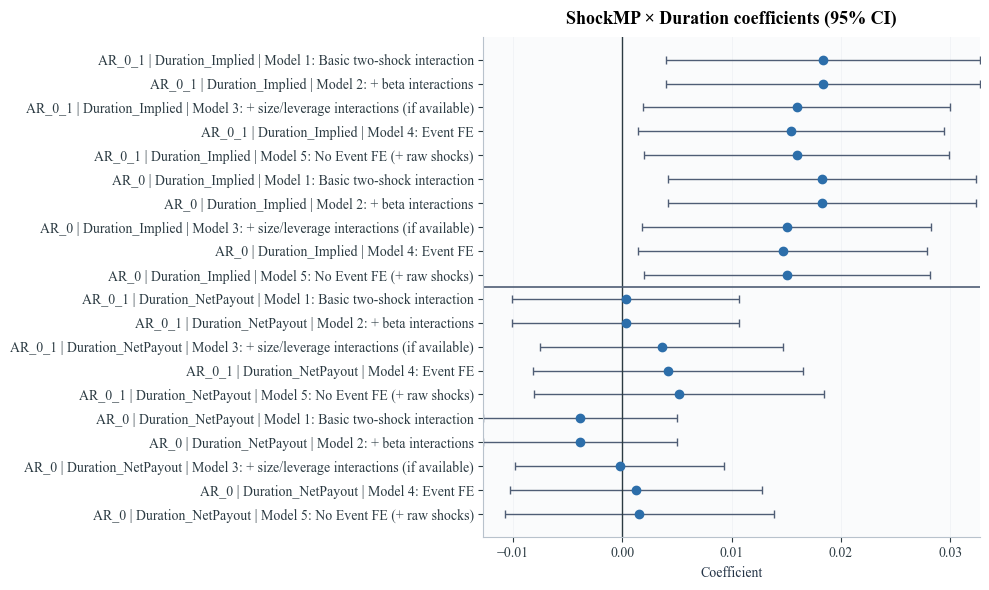

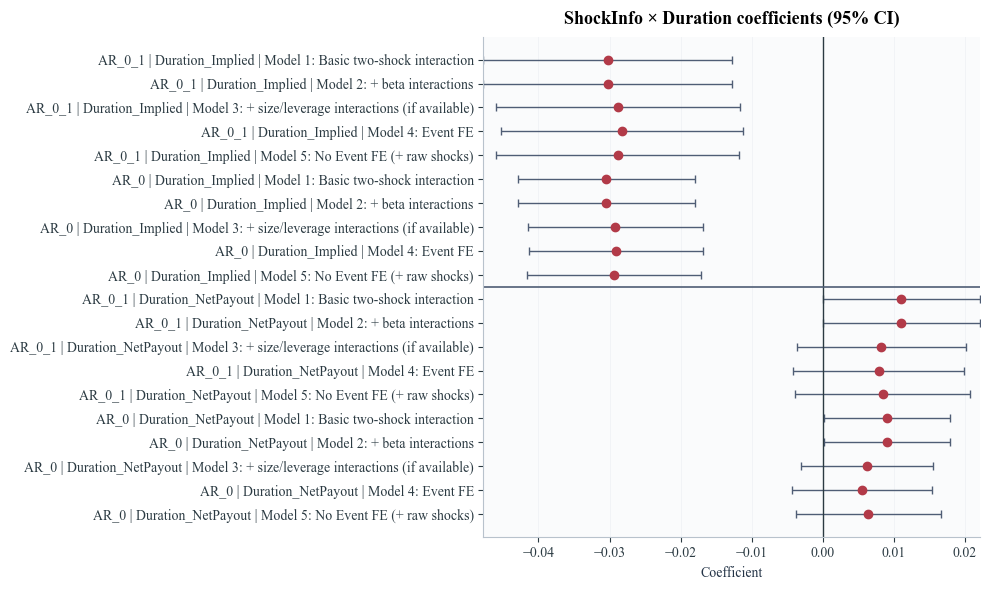

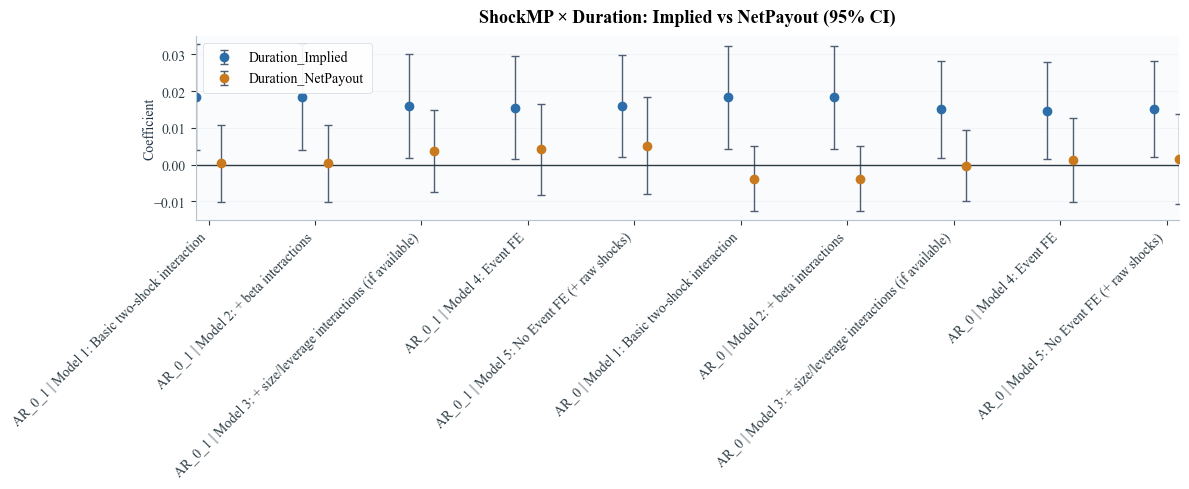

In [23]:
plot_df = df_results.copy()
plot_df['label'] = plot_df['depvar'] + ' | ' + plot_df['duration_name'].str.replace('_std', '', regex=False) + ' | ' + plot_df['specification_name']

duration_order_map = {
    'Duration_Implied_std': 0,
    'Duration_NetPayout_std': 1,
}
depvar_order_map = {
    'AR_0_1': 0,
    'AR_0': 1,
}
spec_order_map = {
    'Model 1: Basic two-shock interaction': 0,
    'Model 2: + beta interactions': 1,
    'Model 3: + size/leverage interactions (if available)': 2,
    'Model 4: Event FE': 3,
    'Model 5: No Event FE (+ raw shocks)': 4,
}

def coef_ci_ordered(df, coef_col, se_col):
    d = df[['label', 'duration_name', 'depvar', 'specification_name', coef_col, se_col]].dropna().copy()
    d['duration_order'] = d['duration_name'].map(duration_order_map).fillna(99)
    d['depvar_order'] = d['depvar'].map(depvar_order_map).fillna(99)
    d['spec_order'] = d['specification_name'].map(spec_order_map).fillna(99)
    d = d.sort_values(['duration_order', 'depvar_order', 'spec_order']).reset_index(drop=True)
    d['lo'] = d[coef_col] - 1.96 * d[se_col]
    d['hi'] = d[coef_col] + 1.96 * d[se_col]
    return d

# Plot 1: ShockMP x Duration
p1 = coef_ci_ordered(plot_df, 'coef_mp_duration', 'se_mp_duration')
fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(p1))))
y = np.arange(len(p1))
ax.errorbar(
    p1['coef_mp_duration'],
    y,
    xerr=1.96 * p1['se_mp_duration'],
    fmt='o',
    color=COLORS['blue'],
    ecolor=COLORS['neutral'],
    capsize=3,
)
ax.axvline(0, color=COLORS['reference'], linewidth=1)

if p1['duration_name'].eq('Duration_Implied_std').any() and p1['duration_name'].eq('Duration_NetPayout_std').any():
    split_idx = int(p1['duration_name'].eq('Duration_Implied_std').sum())
    ax.axhline(split_idx - 0.5, color=COLORS['neutral'], linewidth=1.2)

ax.set_yticks(y)
ax.set_yticklabels(p1['label'])
ax.invert_yaxis()
ax.set_title('ShockMP × Duration coefficients (95% CI)')
ax.set_xlabel('Coefficient')
style_axes(ax, grid_axis='x', grid_alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 2: ShockInfo x Duration
p2 = coef_ci_ordered(plot_df, 'coef_info_duration', 'se_info_duration')
fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(p2))))
y = np.arange(len(p2))
ax.errorbar(
    p2['coef_info_duration'],
    y,
    xerr=1.96 * p2['se_info_duration'],
    fmt='o',
    color=COLORS['accent'],
    ecolor=COLORS['neutral'],
    capsize=3,
)
ax.axvline(0, color=COLORS['reference'], linewidth=1)

if p2['duration_name'].eq('Duration_Implied_std').any() and p2['duration_name'].eq('Duration_NetPayout_std').any():
    split_idx = int(p2['duration_name'].eq('Duration_Implied_std').sum())
    ax.axhline(split_idx - 0.5, color=COLORS['neutral'], linewidth=1.2)

ax.set_yticks(y)
ax.set_yticklabels(p2['label'])
ax.invert_yaxis()
ax.set_title('ShockInfo × Duration coefficients (95% CI)')
ax.set_xlabel('Coefficient')
style_axes(ax, grid_axis='x', grid_alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 3: side-by-side Implied vs NetPayout
p3 = plot_df[plot_df['duration_name'].isin(['Duration_Implied_std', 'Duration_NetPayout_std'])].copy()
p3['depvar_order'] = p3['depvar'].map(depvar_order_map).fillna(99)
p3['spec_order'] = p3['specification_name'].map(spec_order_map).fillna(99)
p3 = p3.sort_values(['depvar_order', 'spec_order', 'duration_name'])
base_labels = p3[['depvar', 'specification_name', 'depvar_order', 'spec_order']].drop_duplicates().sort_values(['depvar_order', 'spec_order']).reset_index(drop=True)
base_labels['x'] = np.arange(len(base_labels))
p3 = p3.merge(base_labels[['depvar', 'specification_name', 'x']], on=['depvar', 'specification_name'], how='left')

fig, ax = plt.subplots(figsize=(12, 5))
for dur, offset, color in [
    ('Duration_Implied_std', -0.12, COLORS['blue']),
    ('Duration_NetPayout_std', 0.12, COLORS['orange']),
]:
    d = p3[p3['duration_name'] == dur]
    ax.errorbar(
        d['x'] + offset,
        d['coef_mp_duration'],
        yerr=1.96 * d['se_mp_duration'],
        fmt='o',
        color=color,
        ecolor=COLORS['neutral'],
        capsize=3,
        label=dur.replace('_std', ''),
    )

ax.axhline(0, color=COLORS['reference'], linewidth=1)
ax.set_xticks(base_labels['x'])
ax.set_xticklabels(base_labels['depvar'] + ' | ' + base_labels['specification_name'], rotation=45, ha='right')
ax.set_title('ShockMP × Duration: Implied vs NetPayout (95% CI)')
ax.set_ylabel('Coefficient')
style_axes(ax, grid_axis='y', grid_alpha=0.25)
style_legend(ax, loc='best')
plt.tight_layout()
plt.show()

## 10. Export output tables

In [24]:
# Wald tests: H0 beta(ShockMP x Duration) = beta(ShockInfo x Duration)
wald_rows = []
for _, r in df_results.iterrows():
    res = r['model_obj']
    dur = r['duration_name']
    mp_term = f'ShockMP:{dur}'
    info_term = f'ShockInfo:{dur}'
    if mp_term not in res.params.index or info_term not in res.params.index:
        continue

    R = np.zeros((1, len(res.params)))
    names = list(res.params.index)
    R[0, names.index(mp_term)] = 1.0
    R[0, names.index(info_term)] = -1.0
    wt = res.wald_test(R, scalar=True)

    beta_mp = float(res.params[mp_term])
    beta_info = float(res.params[info_term])
    wald_rows.append({
        'Duration': dur.replace('_std', '').replace('Duration_', ''),
        'Return window': r['depvar'],
        'Specification': r['specification_name'],
        'beta_MP': beta_mp,
        'beta_Info': beta_info,
        'difference': beta_mp - beta_info,
        'Wald p-value': float(wt.pvalue),
    })

regression_results_main = df_results.drop(columns=['model_obj']).copy()
regression_results_reader = TABLE_READER.copy()
regression_results_wald = pd.DataFrame(wald_rows)

TABLE_DIR.mkdir(parents=True, exist_ok=True)
regression_results_main.to_csv(TABLE_DIR / 'regression_results_main.csv', index=False)
regression_results_reader.to_csv(TABLE_DIR / 'regression_results_reader.csv', index=False)
regression_results_wald.to_csv(TABLE_DIR / 'regression_results_wald.csv', index=False)

# Optional LaTeX export
latex_cols = [
    'depvar', 'duration_name', 'specification_name', 'event_FE', 'controls',
    'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
    'coef_info_duration', 't_info_duration', 'p_info_duration',
    'N', 'n_events', 'r_squared'
]
regression_results_main[latex_cols].to_latex(TABLE_DIR / 'regression_results_main.tex', index=False, float_format='%.4f')

print('Exported:')
print(TABLE_DIR / 'regression_results_main.csv')
print(TABLE_DIR / 'regression_results_reader.csv')
print(TABLE_DIR / 'regression_results_wald.csv')
print(TABLE_DIR / 'regression_results_main.tex')

Exported:
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_main.csv
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_reader.csv
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_wald.csv
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_results_main.tex


## Interpretation Notes

- `ShockMP × Duration`: under tightening surprises, a more negative coefficient is consistent with stronger losses for long-duration equities.
- `ShockInfo × Duration`: sign is ambiguous a priori because information shocks can combine discount-rate and cash-flow effects.
- Event FE models isolate within-event cross-sectional variation across firms.
- No Event FE models additionally use cross-event variation in shock magnitudes.